<a href="https://colab.research.google.com/github/leejsya/PyTorch/blob/main/Abalone_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. 라이브러리 및 모듈 임포트

In [6]:
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim

# 2. 데이터 전처리

In [7]:
''' 데이터 불러오기 '''
abalone_df = pd.read_csv(
    'https://storage.googleapis.com/download.tensorflow.org/data/abalone_train.csv',
    names=['Length', 'Diameter', 'Height', 'Whole weight', 'Shucked weight',
           'Viscera weight', 'Shell weight', 'Age']
)

''' input & target 설정 '''
input_data = abalone_df.drop(columns=['Age']).to_numpy().astype(np.float32)
target_data = abalone_df['Age'].to_numpy().astype(np.float32)

In [8]:
''' 데이터셋 클래스 정의 '''
class AbaloneDataset(Dataset):
    def __init__(self, input_data, target_data):
        self.input_data = input_data
        self.target_data = target_data

    def __len__(self):
        return len(self.input_data)

    def __getitem__(self, index):
        input_tensor = torch.tensor(self.input_data[index], dtype=torch.float32)
        target_tensor = torch.tensor(self.target_data[index], dtype=torch.float32)

        return input_tensor, target_tensor

''' train/val/test 분할 '''
# 0.8 : 0.1 : 0.1 로 분할
train_size = int(len(input_data) * 0.8)
val_size = int(len(input_data) * 0.1)

train_inputs = input_data[:train_size]
train_targets = target_data[:train_size]

val_inputs = input_data[train_size:train_size + val_size]
val_targets = target_data[train_size:train_size + val_size]

test_inputs = input_data[train_size + val_size:]
test_targets = target_data[train_size + val_size:]

''' Standardization '''
scaler = StandardScaler()
scaler.fit(train_inputs)

train_inputs_scaled = scaler.transform(train_inputs)
val_inputs_scaled = scaler.transform(val_inputs)
test_inputs_scaled = scaler.transform(test_inputs)

''' Dataset obejct 생성 '''
train_dataset = AbaloneDataset(train_inputs_scaled, train_targets)
val_dataset = AbaloneDataset(val_inputs_scaled, val_targets)
test_dataset = AbaloneDataset(test_inputs_scaled, test_targets)

''' Dataloader object 생성 '''
train_dataloader = DataLoader(dataset=train_dataset, batch_size=32, shuffle=True, drop_last=True)
val_dataloader = DataLoader(dataset=val_dataset, batch_size=32)
test_dataloader = DataLoader(dataset=test_dataset, batch_size=32)

# 3. 모델 정의 및 생성

In [9]:
''' 모델 클래스 정의 '''
class AbaloneModel(nn.Module):
    def __init__(self):
        super().__init__()
        # layer 정의
        self.fc1 = nn.Linear(7, 32)
        self.fc2 = nn.Linear(32, 16)
        self.fc3 = nn.Linear(16, 8)
        self.fc4 = nn.Linear(8, 1)
        # Activation Function 정의
        self.relu = nn.ReLU()
        # Dropout 정의
        self.dropout = nn.Dropout()

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.relu(self.fc3(x))
        # 학습 때는 일부 뉴런을 비활성화, 추론 때는 모든 뉴런을 사용
        x = self.dropout(x)
        x = self.fc4(x)
        return x

''' 모델 생성 '''
model = AbaloneModel()

''' Loss Function 생성 '''
loss_fn = nn.MSELoss()

''' 연산 장치 설정 '''
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

''' optimizer 생성 '''
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)

# 4. 모델 학습 및 검증

In [10]:
epochs = 10

for epoch in range(epochs):

    # training을 목적으로 동작하도록 설정 - dropout 적용하기
    model.train()

    ''' Training Loop '''
    for train_batch in train_dataloader:
        x_train, y_train = train_batch[0].to(device), train_batch[1].to(device)
        pred = model(x_train).squeeze()

        # pred와 y_train의 loss 구하기
        loss = loss_fn(pred, y_train)

        # loss를 통해 gradient 계산(autograd)
        loss.backward()

        # gradient를 통해 parameter 업데이트
        optimizer.step()
        # model parameter tensor에 저장되어 있던 gradient를 모두 리셋
        optimizer.zero_grad()


    # validation을 목적으로 동작하도록 설정 - dropout 적용하지 않기
    model.eval()

    ''' Validation Loop '''
    # 검증할 때는 gradient 계산이 필요 없음(연산 효율 증가)
    with torch.no_grad():
        losses = []
        for val_batch in val_dataloader:
            x_val, y_val = val_batch[0].to(device), val_batch[1].to(device)
            pred = model(x_val).squeeze()
            loss = loss_fn(pred, y_val)
            losses.append(loss.item())

        # 한 epoch마다 loss값의 평균을 계산해 출력
        val_loss_avg = sum(losses) / len(losses)
        print(f"epoch {epoch+1}/{epochs}, validation loss: {val_loss_avg:.4f}\n")

epoch 1/10, validation loss: 5.1115

epoch 2/10, validation loss: 5.5298

epoch 3/10, validation loss: 5.8122

epoch 4/10, validation loss: 7.4099

epoch 5/10, validation loss: 8.2980

epoch 6/10, validation loss: 5.5379

epoch 7/10, validation loss: 6.1716

epoch 8/10, validation loss: 5.7224

epoch 9/10, validation loss: 5.1560

epoch 10/10, validation loss: 5.1221



# 5. 모델 성능 평가

In [11]:
''' Test Loop '''
model.eval()
with torch.no_grad():
  losses = []
  preds = []
  targets = []
  for test_batch in test_dataloader:
      x_test, y_test = test_batch[0].to(device), test_batch[1].to(device)
      pred = model(x_test).squeeze()
      loss = loss_fn(pred, y_test)
      losses.append(loss.item())

      # pred와 y_test는 배치 단위 tensor이기 때문에 extend로 리스트에 넣어주기
      # GPU에 있는 tensor로는 그래프를 그릴 수 없기 때문에 CPU로 이동시키고 np array로 변환시킴
      preds.extend(pred.cpu().numpy())
      targets.extend(y_test.cpu().numpy())

  # loss의 평균값을 계산하여 출력
  test_loss_avg = sum(losses) / len(losses)
  print(f"test loss: {test_loss_avg:.4f}\n")

test loss: 6.8839



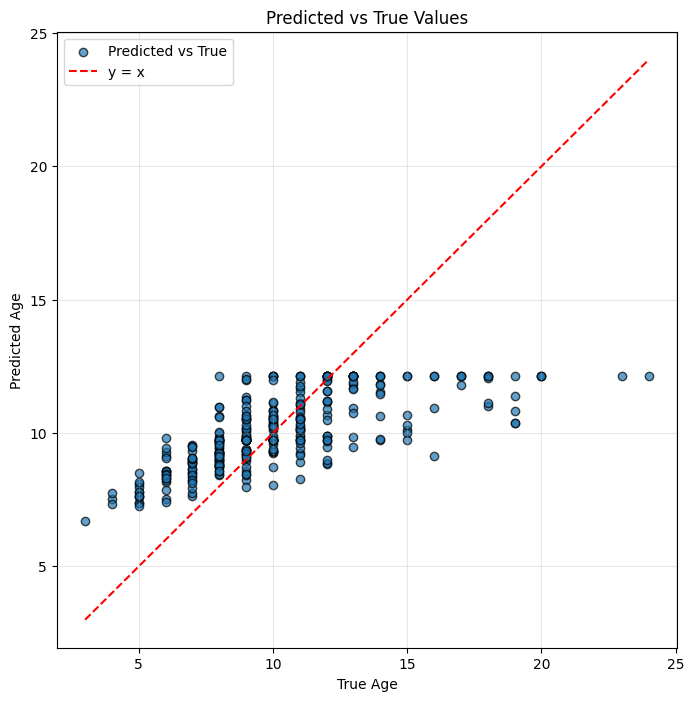

In [13]:
''' 성능 평가 시각화 '''
import matplotlib.pyplot as plt

plt.figure(figsize=(8,8))
plt.scatter(targets, preds, alpha=0.7, label='Predicted vs True', edgecolor='k')

# 비교를 위한 y = x 직선
min_val = min(min(targets), min(preds))
max_val = max(max(targets), max(preds))
plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='y = x')

plt.title('Predicted vs True Values')
plt.xlabel("True Age")
plt.ylabel('Predicted Age')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# 6. 모델 저장 및 불러오기

In [15]:
''' 저장할 정보 확인 '''
state_dict = model.state_dict()
state_dict

OrderedDict([('fc1.weight',
              tensor([[-3.7618e-01,  1.0384e-01,  6.0568e-01,  7.4027e-01, -1.0510e+00,
                       -5.9380e-01,  1.0896e+00],
                      [ 3.2304e-01, -1.6351e-01,  2.7317e-02,  4.7569e-02, -1.5193e-01,
                       -5.5724e-02,  5.1754e-01],
                      [-1.2529e-01, -2.0886e-01, -6.0766e-01, -3.7662e-01,  6.0301e-02,
                        2.6360e-01,  6.1614e-02],
                      [-2.0133e-02,  2.6539e-01,  2.7556e-01,  2.7172e-01,  5.9674e-01,
                       -1.1140e-01, -5.2478e-01],
                      [ 1.4739e-01,  1.0067e-01,  6.3934e-02, -6.1449e-02, -1.7782e-02,
                        2.4588e-01, -2.1932e-01],
                      [-1.6552e-02, -3.0413e-01,  4.5706e-01,  2.7730e-01,  8.7300e-02,
                       -3.7983e-01,  7.7850e-02],
                      [-1.3989e-01, -3.3912e-01,  2.1513e-02,  1.2398e-01, -3.5127e-01,
                        1.3570e-01,  9.7064e-01],
      

In [17]:
''' 모델 결과 저장 '''
torch.save(model.state_dict(), 'model.pth')

In [18]:
''' 모델 결과 불러오기 '''
state_dict_loaded = torch.load('model.pth', weights_only=True)

In [19]:
''' 새로운 모델에 학습 결과 적용시키기 '''
# 새로운 모델 생성
new_model = AbaloneModel()
# 새 모델에 학습 결과 적용
new_model.load_state_dict(state_dict_loaded)

<All keys matched successfully>